# 1. Import libraries and packages 

In [33]:
import os
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

# 2. Data Ingestion and load

In [34]:
def read_data(path: str) -> pd.DataFrame:
    if path.split('.')[-1] == 'csv':
        df = pd.read_csv(path)
    elif path.split('.')[-1] in ['xls', 'xlsx']:
        df = pd.read_excel(path)
    else:
        raise ValueError("Unsupported file format. Please provide a CSV or Excel file.")
    return df

In [35]:
raw_df = read_data('/Users/aadityaraj/Projects/Forecasting_Master/Demand_forecasting/demand_forecasting_FMCG/data/FMCG_2022_2024.csv')
print(raw_df.shape)
raw_df.head()

(190757, 14)


,date,sku,brand,segment,category,channel,region,pack_type,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,units_sold
0,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-Central,Multipack,2.38,0,1,141,128,9
1,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-North,Single,1.55,1,3,0,129,0
2,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-South,Carton,4.00,0,5,118,161,8
3,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-Central,Single,5.16,0,2,81,114,7
4,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-North,Single,7.66,0,4,148,204,12


Inspired by real-world scenarios (e.g. Nestlé, Unilever, P&G), it includes:

* Product hierarchy: SKU → Brand → Segment → Category
* Sales channels: Retail / Discount / E-commerce
* Regions: Central, North, and South (Poland)
* Daily sales quantities, prices, promotions, stock, delivery lag (lead time)
* Pack types: Single / Multipack / Carton
* Seasonality and product introductions:
* New SKUs are introduced in 2024 only
* Prices gradually increase over the years

# 3. Cleaning & Preprocessing 

In [36]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190757 entries, 0 to 190756
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   date             190757 non-null  object 
 1   sku              190757 non-null  object 
 2   brand            190757 non-null  object 
 3   segment          190757 non-null  object 
 4   category         190757 non-null  object 
 5   channel          190757 non-null  object 
 6   region           190757 non-null  object 
 7   pack_type        190757 non-null  object 
 8   price_unit       190757 non-null  float64
 9   promotion_flag   190757 non-null  int64  
 10  delivery_days    190757 non-null  int64  
 11  stock_available  190757 non-null  int64  
 12  delivered_qty    190757 non-null  int64  
 13  units_sold       190757 non-null  int64  
dtypes: float64(1), int64(5), object(8)
memory usage: 20.4+ MB


1. check missing values and data types

In [37]:
# check if dates are missing 
raw_df['date'] = pd.to_datetime(raw_df['date'], format='%Y-%m-%d')
date_range = pd.date_range(start=raw_df['date'].min(), end=raw_df['date'].max())
print(raw_df['date'].min(), raw_df['date'].max())
missing_dates = date_range.difference(raw_df['date'])
print("Missing Dates:", missing_dates)

# check duplicates
duplicates = raw_df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

raw_df.isna().sum()

2022-01-21 00:00:00 2024-12-31 00:00:00
Missing Dates: DatetimeIndex([], dtype='datetime64[ns]', freq='D')
Number of duplicate rows: 0


date               0
sku                0
brand              0
segment            0
category           0
channel            0
region             0
pack_type          0
price_unit         0
promotion_flag     0
delivery_days      0
stock_available    0
delivered_qty      0
units_sold         0
dtype: int64

2. convert categorical features into numeric 


In [38]:

df = raw_df.copy()

encoder = LabelEncoder()

df['sku_encoded'] = encoder.fit_transform(df['sku'])
df['brand_encoded'] = encoder.fit_transform(df['brand'])
df['segment_encoded'] = encoder.fit_transform(df['segment'])
df["category_encoded"] = encoder.fit_transform(df["category"])
df['channel_encoded'] = encoder.fit_transform(df['channel'])
df['region_encoded'] = encoder.fit_transform(df['region'])
df['pack_type_encoded'] = encoder.fit_transform(df['pack_type'])

df.head()

,date,sku,brand,segment,category,channel,region,pack_type,price_unit,promotion_flag,...,stock_available,delivered_qty,units_sold,sku_encoded,brand_encoded,segment_encoded,category_encoded,channel_encoded,region_encoded,pack_type_encoded
0,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-Central,Multipack,2.38,0,...,141,128,9,2,1,3,1,2,0,1
1,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-North,Single,1.55,1,...,0,129,0,2,1,3,1,2,1,2
2,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-South,Carton,4.00,0,...,118,161,8,2,1,3,1,2,2,0
3,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-Central,Single,5.16,0,...,81,114,7,2,1,3,1,0,0,2
4,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-North,Single,7.66,0,...,148,204,12,2,1,3,1,0,1,2


3. sanity checks

In [39]:
# sanity checks

sold_item_check = df[df['units_sold'] > df['stock_available']]
print("Rows where units_sold > stock_available:", sold_item_check.shape[0])

unit_sold_check = df[df['units_sold'] > df['delivered_qty']]
print("Rows where units_sold > delivered_qty:", unit_sold_check.shape[0])

negative_values_check = df[(df['units_sold'] < 0) | (df['delivered_qty'] < 0) | (df['stock_available'] < 0)]
print("Rows with negative values in units_sold, delivered_qty, or stock_available:", negative_values_check.shape[0])

df = df[df['units_sold'] >= 0]
df = df[df['delivered_qty'] >= 0]
df = df[df['stock_available'] >= 0]

negative_values_check = df[(df['units_sold'] < 0) | (df['delivered_qty'] < 0) | (df['stock_available'] < 0)]
print("Rows with negative values in units_sold, delivered_qty, or stock_available:", negative_values_check.shape[0])


Rows where units_sold > stock_available: 0
Rows where units_sold > delivered_qty: 0
Rows with negative values in units_sold, delivered_qty, or stock_available: 3
Rows with negative values in units_sold, delivered_qty, or stock_available: 0


4. Aggregate data to daily level for SKUs, brands, categories, and segmentsm,region,channel,pack_type

In [40]:
sku_df = (
    df.groupby(
        ['date','sku','brand','segment','category',
         'region','channel','pack_type'],
        as_index=False
    )
    .agg({
        'units_sold': 'sum',
        'delivered_qty': 'sum',
        'price_unit': 'mean',
        'promotion_flag': 'max',
        'stock_available': 'mean',
        'delivery_days': 'mean'
    })
)

In [41]:
print(sku_df.shape)
sku_df.head()


(190754, 14)


,date,sku,brand,segment,category,region,channel,pack_type,units_sold,delivered_qty,price_unit,promotion_flag,stock_available,delivery_days
0,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,PL-Central,Discount,Single,7,114,5.16,0,81.0,2.0
1,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,PL-Central,Retail,Multipack,9,128,2.38,0,141.0,1.0
2,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,PL-North,Discount,Single,12,204,7.66,0,148.0,4.0
3,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,PL-North,E-commerce,Carton,7,156,8.58,0,140.0,2.0
4,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,PL-North,Retail,Single,0,129,1.55,1,0.0,3.0


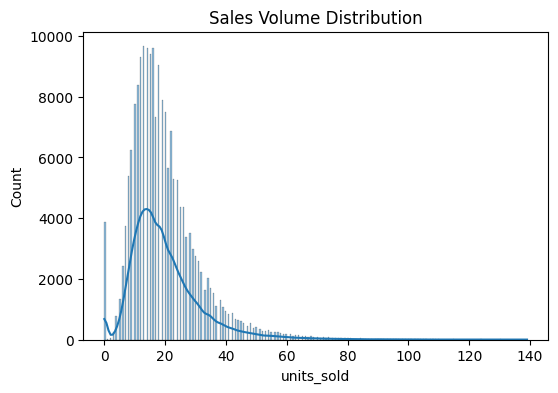

In [42]:
# check data distribution 
df = sku_df.copy()
plt.figure(figsize=(6,4))
sns.histplot(df['units_sold'], kde=True)
plt.title("Sales Volume Distribution")
plt.show()

5. Data cleaning 

In [43]:
# z_scores = (df['units_sold'] - df['units_sold'].mean()) / df['units_sold'].std()
# outliers = df[np.abs(z_scores) > 3]
# print("Number of outliers detected using Z-score method:", outliers.shape[0])

In [44]:
# # Remove outliers
# df = df[np.abs(z_scores) <= 3]
# print("Data shape after removing outliers:", df.shape)

# check_date_range = pd.date_range(start=df['date'].min(), end=df['date'].max())
# missing_dates_after_outlier_removal = check_date_range.difference(df['date'])
# print("Missing Dates after outlier removal:", missing_dates_after_outlier_removal)

In [45]:
# IQR method for outlier detection

Q1 = df['units_sold'].quantile(0.25)
Q3 = df['units_sold'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['units_sold'] < lower_bound) | (df['units_sold'] > upper_bound)]
outliers

without_outliers = df[(df['units_sold'] >= lower_bound) & (df['units_sold'] <= upper_bound)]
print("Data shape after removing IQR outliers:", without_outliers.shape)

check_date_range_iqr = pd.date_range(start=without_outliers['date'].min(), end=without_outliers['date'].max())
missing_dates_after_iqr_removal = check_date_range_iqr.difference(without_outliers['date'])
print("Missing Dates after IQR outlier removal:", missing_dates_after_iqr_removal)

clean_df = without_outliers.copy()

Data shape after removing IQR outliers: (183047, 14)
Missing Dates after IQR outlier removal: DatetimeIndex([], dtype='datetime64[ns]', freq='D')


* **from the above graphs and statistical method we can clearly see there are few outliers to handle, data need to clean

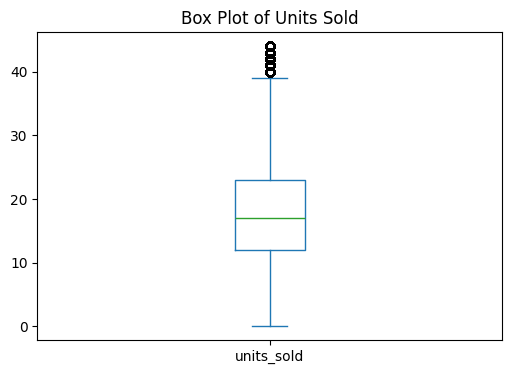

In [46]:
# check outliers using box plot

clean_df.plot(kind='box', y='units_sold', figsize=(6,4))
plt.title("Box Plot of Units Sold")
plt.show()

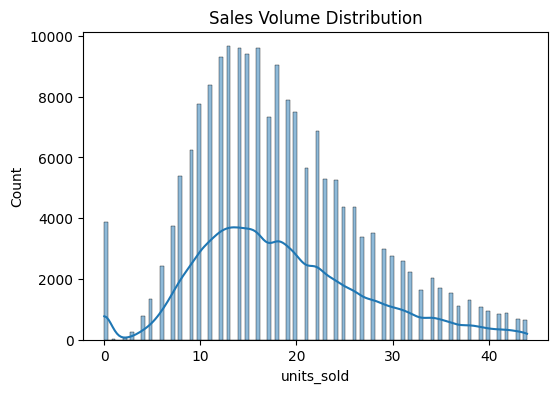

In [47]:
# check data distribution 

plt.figure(figsize=(6,4))
sns.histplot(clean_df['units_sold'], kde=True)
plt.title("Sales Volume Distribution")
plt.show()

In [48]:
clean_df.groupby('promotion_flag')['units_sold'].agg(['count', 'mean', 'median', 'std'])


,count,mean,median,std
promotion_flag,,,,
0,161021,17.177188,16.0,7.919955
1,22026,26.944611,27.0,9.859601


# 4. EDA 

- check impact of promotion 

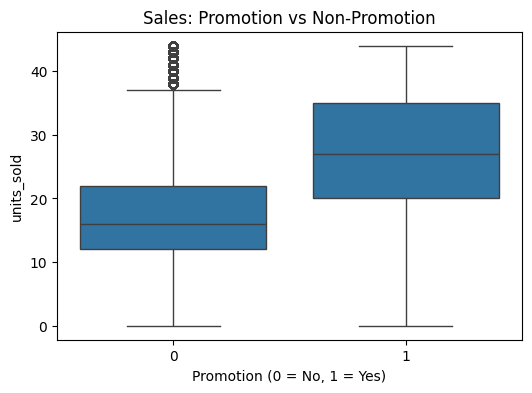

In [49]:


plt.figure(figsize=(6,4))
sns.boxplot(x='promotion_flag', y='units_sold', data=clean_df)
plt.title("Sales: Promotion vs Non-Promotion")
plt.xlabel("Promotion (0 = No, 1 = Yes)")
plt.show()


- Sales over time 

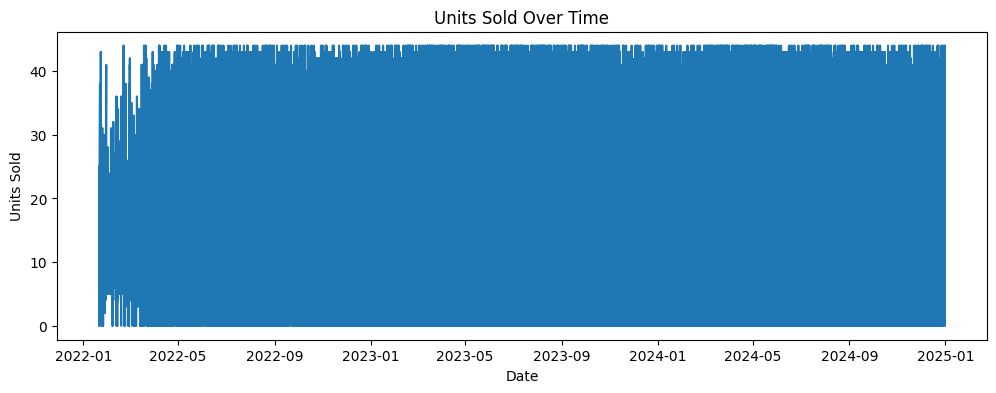

In [50]:
plt.figure(figsize=(12,4))
plt.plot(clean_df['date'], clean_df['units_sold'])
plt.title("Units Sold Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()


<Axes: ylabel='Density'>

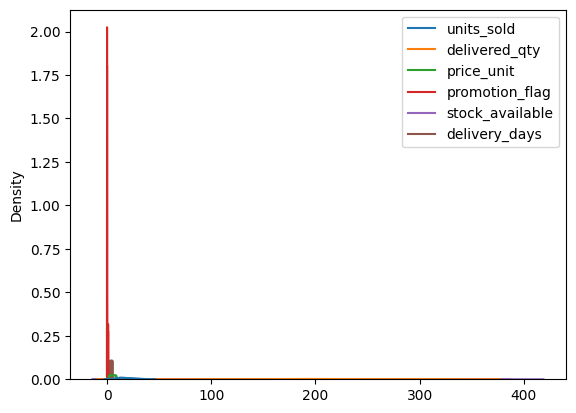

In [51]:
clean_df["units_sold"].value_counts().head()
clean_df.groupby(clean_df["date"].dt.month)["units_sold"].max()
sns.kdeplot(df, label="Before")
sns.kdeplot(clean_df, label="After")


# 5. Feature Engineering and Transformation 

In [52]:
# create lag faetures 

clean_df = clean_df.sort_values('date')

# for volume 
clean_df['sales_lag_1'] = clean_df['units_sold'].shift(1)
clean_df['sales_lag_7'] = clean_df['units_sold'].shift(7)
clean_df['sales_lag_14'] = clean_df['units_sold'].shift(14)

# for price
clean_df['delivered_qty_lag_1'] = clean_df['delivered_qty'].shift(1)
clean_df['delivered_qty_lag_7'] = clean_df['delivered_qty'].shift(7)
clean_df['delivered_qty_lag_14'] = clean_df['delivered_qty'].shift(14)

# for promo
clean_df['promo_lag_1'] = clean_df['promotion_flag'].shift(1)
clean_df['promo_lag_7'] = clean_df['promotion_flag'].shift(7)
# for stock level/existing stock
clean_df['stock_available_lag1'] = clean_df['stock_available'].shift(1)
clean_df['stock_available_lag7'] = clean_df['stock_available'].shift(7)
# rolling statistics features
clean_df['sales_roll_mean_7'] = clean_df['units_sold'].shift(1).rolling(7).mean()
clean_df['sales_roll_std_7'] = clean_df['units_sold'].shift(1).rolling(7).std()
clean_df['sales_roll_mean_28'] = clean_df['units_sold'].shift(1).rolling(28).mean()
clean_df = clean_df.dropna()
clean_df.head()

,date,sku,brand,segment,category,region,channel,pack_type,units_sold,delivered_qty,...,delivered_qty_lag_1,delivered_qty_lag_7,delivered_qty_lag_14,promo_lag_1,promo_lag_7,stock_available_lag1,stock_available_lag7,sales_roll_mean_7,sales_roll_std_7,sales_roll_mean_28
24,2022-01-23,MI-006,MiBrand1,Milk-Seg3,Milk,PL-North,E-commerce,Carton,10,140,...,246.0,151.0,192.0,1.0,0.0,285.0,132.0,16.571429,12.094863,13.714286
23,2022-01-23,MI-006,MiBrand1,Milk-Seg3,Milk,PL-North,Discount,Carton,15,189,...,140.0,111.0,198.0,0.0,1.0,96.0,124.0,16.714286,11.996031,13.821429
22,2022-01-23,MI-006,MiBrand1,Milk-Seg3,Milk,PL-Central,Retail,Carton,11,232,...,189.0,185.0,161.0,0.0,0.0,213.0,176.0,16.571429,12.011899,14.035714
21,2022-01-23,MI-006,MiBrand1,Milk-Seg3,Milk,PL-Central,E-commerce,Single,10,161,...,232.0,139.0,140.0,0.0,0.0,213.0,130.0,15.857143,12.198751,14.000000
20,2022-01-23,MI-006,MiBrand1,Milk-Seg3,Milk,PL-Central,Discount,Carton,14,140,...,161.0,127.0,249.0,0.0,0.0,153.0,149.0,16.000000,12.110601,14.107143


# Correlation & Relationship Analysis

In [53]:
numeric_cols = clean_df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = clean_df[numeric_cols].corr()
corr_matrix


,units_sold,delivered_qty,price_unit,promotion_flag,stock_available,delivery_days,sales_lag_1,sales_lag_7,sales_lag_14,delivered_qty_lag_1,delivered_qty_lag_7,delivered_qty_lag_14,promo_lag_1,promo_lag_7,stock_available_lag1,stock_available_lag7,sales_roll_mean_7,sales_roll_std_7,sales_roll_mean_28
units_sold,1.000000,0.398970,-0.001997,0.362196,0.620085,0.003028,0.128548,0.084917,0.067184,-0.007907,-0.002458,-0.002681,-0.014854,-0.012651,-0.011048,-0.005499,0.210538,0.084219,0.210130
delivered_qty,0.398970,1.000000,-0.003799,-0.063721,0.656502,0.001872,-0.004872,-0.008135,0.003858,-0.001372,0.000516,0.000337,0.006601,0.000665,-0.001731,-0.002527,-0.013360,-0.007314,-0.009835
price_unit,-0.001997,-0.003799,1.000000,0.002510,-0.002055,0.002417,0.000433,0.002044,0.001354,0.001944,0.003008,0.000069,0.002379,0.002498,0.000421,0.002722,0.002213,0.003117,-0.001022
promotion_flag,0.362196,-0.063721,0.002510,1.000000,-0.084009,-0.001110,-0.017871,-0.012922,-0.009981,0.001569,0.002642,-0.000137,0.006210,0.002487,0.004422,0.000949,-0.038036,-0.019288,-0.035750
stock_available,0.620085,0.656502,-0.002055,-0.084009,1.000000,0.002500,-0.008506,-0.007420,-0.000368,0.000362,-0.000107,0.004351,0.006982,0.002876,-0.001652,-0.001751,-0.016889,-0.007816,-0.015199
delivery_days,0.003028,0.001872,0.002417,-0.001110,0.002500,1.000000,0.000151,0.000692,-0.001611,-0.000477,0.002789,-0.002647,-0.001098,0.000849,0.000283,0.002270,0.000652,0.003022,-0.000174
sales_lag_1,0.128548,-0.004872,0.000433,-0.017871,-0.008506,0.000151,1.000000,0.086027,0.071103,0.398992,-0.006353,0.000014,0.362222,-0.014476,0.620100,-0.007740,0.477312,0.203086,0.309935
sales_lag_7,0.084917,-0.008135,0.002044,-0.012922,-0.007420,0.000692,0.086027,1.000000,0.084898,-0.006471,0.398999,-0.002472,-0.016860,0.362217,-0.008755,0.620093,0.477326,0.200530,0.343558
sales_lag_14,0.067184,0.003858,0.001354,-0.009981,-0.000368,-0.001611,0.071103,0.084898,1.000000,-0.002279,-0.008139,0.399009,-0.010125,-0.012934,-0.001709,-0.007434,0.153824,0.063471,0.355954
delivered_qty_lag_1,-0.007907,-0.001372,0.001944,0.001569,0.000362,-0.000477,0.398992,-0.006471,-0.002279,1.000000,-0.002163,0.006327,-0.063691,0.001523,0.656513,-0.001253,0.105330,0.020496,0.032199


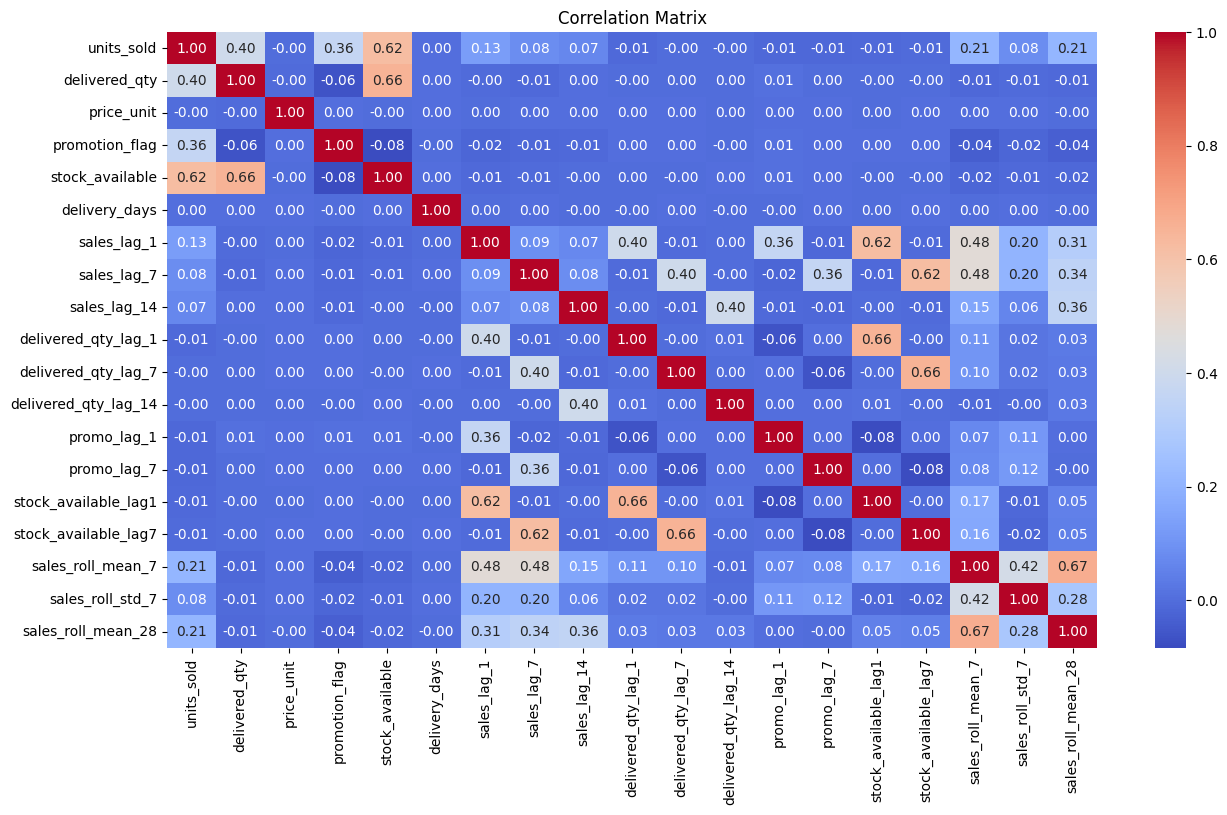

In [54]:
plt.figure(figsize=(15,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()


# Feature Selection 

1.Mutual Information (Best First Upgrade)
Why it works

* Measures any dependency, not just linear

* Detects threshold & step effects (e.g., promotions)

* When to use: ** 

* Early feature screening

* Mixed data types

* Before model training

In [55]:
from sklearn.feature_selection import mutual_info_regression

threshold = 20  # Define your threshold value here
clean_df['low_stock_flag'] = (clean_df['stock_available'] <= threshold).astype(int)

X = clean_df.drop(columns=['units_sold'])
X= X.select_dtypes(include=[np.number])
y = clean_df['units_sold']
mi = mutual_info_regression(X, y, random_state=42)
mi_scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)

mi_scores


stock_available         0.347252
delivered_qty           0.125073
low_stock_flag          0.099197
promotion_flag          0.069706
sales_roll_mean_28      0.029369
sales_roll_mean_7       0.025375
sales_lag_1             0.011489
sales_roll_std_7        0.005152
sales_lag_7             0.003115
promo_lag_1             0.002835
sales_lag_14            0.001256
price_unit              0.000840
delivered_qty_lag_1     0.000737
delivery_days           0.000642
promo_lag_7             0.000213
delivered_qty_lag_7     0.000002
delivered_qty_lag_14    0.000000
stock_available_lag1    0.000000
stock_available_lag7    0.000000
dtype: float64

2.Tree-Based Feature Importance (Random Forest / XGBoost)
* Why it works

Captures:

* Non-linearity

* Interactions

* Threshold effects

* Industry standard for demand forecasting

In [56]:
from sklearn.ensemble import RandomForestRegressor


model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X, y)

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance


stock_available         0.430087
promotion_flag          0.156226
sales_roll_mean_7       0.067715
sales_roll_mean_28      0.052533
stock_available_lag1    0.030629
sales_roll_std_7        0.028649
price_unit              0.028169
delivered_qty_lag_1     0.026009
delivered_qty_lag_14    0.025902
delivered_qty           0.025456
sales_lag_1             0.025315
delivered_qty_lag_7     0.024717
stock_available_lag7    0.024178
sales_lag_14            0.020970
sales_lag_7             0.018606
delivery_days           0.009056
promo_lag_1             0.003946
promo_lag_7             0.001792
low_stock_flag          0.000046
dtype: float64

# ML Models 

In [66]:
# Linear Regression 
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


imp_features = feature_importance.head(16).index.tolist()

clean_df = clean_df.sort_values('date').reset_index(drop=True)

x = clean_df.drop(columns=['units_sold'])[imp_features]
x = x.select_dtypes(include=[np.number])
y = clean_df['units_sold']

train_size = int(0.8 * len(clean_df))
X_train, X_test = x[:train_size], x[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

lr_model = LinearRegression()
scaler = StandardScaler()

# Fit on train set and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model.fit(X_train_scaled, y_train)
y_pred = lr_model.predict(X_test_scaled)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)


In [67]:
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"MAPE: {mape}%")
print(f"RMSE: {rmse}")
print(f"R-squared: {r2}")

MAE: 3.6142091200920845
MSE: 22.170224173105414
MAPE: inf%
RMSE: 4.7085267518731815
R-squared: 0.6631687913277293


In [ ]:
# Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor
gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gbr_model.fit(X_train, y_train)
y_pred = gbr_model.predict(X_test)


In [75]:



# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
# mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
smape = np.mean(
    2 * np.abs(y_pred - y_test) / (np.abs(y_test) + np.abs(y_pred) + 1e-8)
) * 100

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"SMAPE: {smape}%")
print(f"RMSE: {rmse}")
print(f"R-squared: {r2}")

MAE: 3.4738556827661298
MSE: 20.818757866691374
SMAPE: 25.275915101621926%
RMSE: 4.562757704140268
R-squared: 0.6837015575241808


In [76]:
# predict for test set

test_dataset = clean_df[train_size:].copy()
test_dataset['predicted_units_sold'] = y_pred
test_dataset

,date,sku,brand,segment,category,region,channel,pack_type,units_sold,delivered_qty,...,delivered_qty_lag_14,promo_lag_1,promo_lag_7,stock_available_lag1,stock_available_lag7,sales_roll_mean_7,sales_roll_std_7,sales_roll_mean_28,low_stock_flag,predicted_units_sold
146415,2024-07-21,YO-024,YoBrand2,Yogurt-Seg3,Yogurt,PL-North,Discount,Single,30,185,...,153.0,0.0,0.0,0.0,182.0,19.428571,9.571784,19.250000,0,20.084073
146416,2024-07-22,MI-002,MiBrand2,Milk-Seg1,Milk,PL-South,Discount,Carton,13,165,...,193.0,0.0,0.0,227.0,249.0,28.714286,8.440266,20.500000,0,19.631279
146417,2024-07-22,MI-002,MiBrand2,Milk-Seg1,Milk,PL-North,Retail,Single,21,197,...,140.0,0.0,0.0,202.0,147.0,28.000000,9.363048,20.821429,0,30.808605
146418,2024-07-22,MI-002,MiBrand2,Milk-Seg1,Milk,PL-North,E-commerce,Single,32,201,...,103.0,0.0,0.0,164.0,185.0,27.428571,9.198861,19.964286,0,24.394504
146419,2024-07-22,MI-002,MiBrand2,Milk-Seg1,Milk,PL-North,Discount,Single,14,159,...,108.0,0.0,0.0,253.0,166.0,27.857143,8.513295,19.642857,0,22.506532
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183014,2024-12-31,SN-019,SnBrand2,SnackBar-Seg1,SnackBar,PL-North,E-commerce,Single,21,167,...,172.0,1.0,0.0,166.0,127.0,22.000000,14.224392,18.250000,0,24.547510
183015,2024-12-31,YO-024,YoBrand2,Yogurt-Seg3,Yogurt,PL-Central,E-commerce,Single,20,237,...,154.0,0.0,0.0,193.0,276.0,23.571429,13.252134,18.714286,0,28.247392
183016,2024-12-31,YO-018,YoBrand2,Yogurt-Seg1,Yogurt,PL-North,Retail,Single,12,176,...,164.0,0.0,0.0,251.0,148.0,21.000000,11.633286,18.964286,0,12.666815
183017,2024-12-31,MI-026,MiBrand4,Milk-Seg2,Milk,PL-North,Discount,Carton,0,183,...,147.0,0.0,0.0,153.0,197.0,18.571429,7.230886,14.357143,1,0.188589


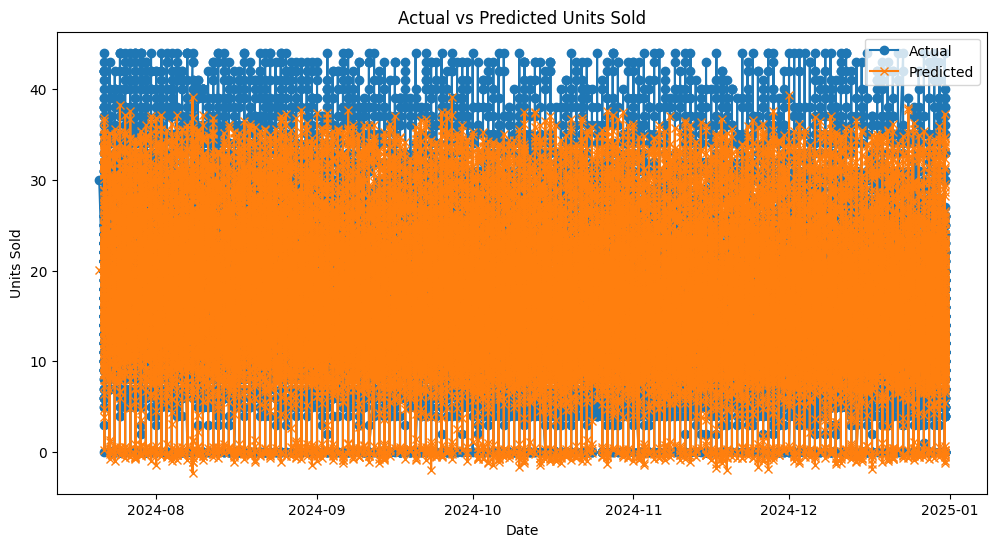

In [77]:
# check difference between actual and predicted using graphs

plt.figure(figsize=(12,6))
plt.plot(test_dataset['date'], test_dataset['units_sold'], label='Actual', marker='o')
plt.plot(test_dataset['date'], test_dataset['predicted_units_sold'], label='Predicted', marker='x')
plt.title("Actual vs Predicted Units Sold")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.show()